In [14]:
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

In [15]:
# Residual Block:
# 각 Block당 Convolution 2개

class Residual(nn.Module):
    def __init__(
        self,
        num_channels: int,
        use_1x1conv: bool = False,
        strides: int = 1,
    ) -> None:
        super().__init__()
        
        # Main Branch:
        # - kernel: 3x3 Convolution 
        # - stride: conv1에서 spatial shape 변경 
        self.conv1 = nn.LazyConv2d(
            out_channels=num_channels,
            kernel_size=3,
            padding=1,
            stride=strides,
        )
        self.conv2 = nn.LazyConv2d(
            out_channels=num_channels,
            kernel_size=3,
            padding=1,
        )
        
        # Batch Normalization
        self.bn1 = nn.LazyBatchNorm2d()
        self.bn2 = nn.LazyBatchNorm2d()
        
        
        # Shortcut Branch: 
        # - kernel: 1x1 Convolution (Projection)
        # - output channel를 Y와 맞추기
        self.conv3: nn.Module | None = (
            nn.LazyConv2d(
                out_channels=num_channels,
                kernel_size=1,
                stride=strides,
            )
            if use_1x1conv
            else None
        )
        
        
    def forward(
        self,
        X: torch.Tensor,
    ) -> torch.Tensor:
        Y = F.relu(
            self.bn1(
                self.conv1(X)
            )
        )
        Y = self.bn2(
            self.conv2(Y)
        )

        shortcut = X

        if self.conv3 is not None:
            shortcut = self.conv3(
                shortcut
            )

        return F.relu(
            Y + shortcut
        )

In [16]:
# ResNet Architecture

class ResNet(d2l.Classifier):
    
    @staticmethod
    def stem() -> nn.Sequential:
        return nn.Sequential(

            # Input:  [B, 1, 96, 96]
            # Output: [B, 64, 48, 48]
            nn.LazyConv2d(
                out_channels=64,
                kernel_size=7,
                stride=2,
                padding=3,
            ),
            nn.LazyBatchNorm2d(),
            nn.ReLU(),
            
            # Input:  [B, 64, 48, 48]
            # Output: [B, 64, 24, 24]
            nn.MaxPool2d(
                kernel_size=3,
                stride=2,
                padding=1,
            ),
        )
        
        
    @staticmethod
    def residual_stage(
        num_residuals: int,
        num_channels: int,
        first_stage: bool = False,
    ) -> nn.Sequential:

        blocks: list[nn.Module] = []
        
        for index in range(
            num_residuals,
        ):
            
            # Stage 2부터 첫 Block에서 
            # channel은 2배, spatial shape는 절반으로 조정
            if index == 0 and not first_stage:
                blocks.append(
                    Residual(
                        num_channels=num_channels,
                        use_1x1conv=True,
                        strides=2,
                    )
                )
            
            # stem()에서 이미 spatial resolution을 줄였으므로
            # Stage 1에서는 output shape 유지
            else:
                blocks.append(
                    Residual(
                        num_channels=num_channels,
                    )
                )

        return nn.Sequential(
            *blocks
        )
        
    def __init__(
        self,
        arch: tuple[
            tuple[int, int],
            ...
        ],
        lr: float = 1e-1,
        num_classes: int = 10
    ) -> None:
        super().__init__()
        
        self.save_hyperparameters()
        
        # 1) Stem: 
        # - 입력 이미지를 처음 받아서 spatial 크기를 줄이고 채널을 늘림.
        # - Deep Network에 들어가기 전에 기본적인 low-level feature를 추출.
        self.net = nn.Sequential(
            self.stem(),
        )
        
        # 2) Residual Stage 추가
        for index, (
            num_residuals,
            num_channels,
        ) in enumerate(
            arch
        ):
            self.net.add_module(
                f"b{index + 2}",
                self.residual_stage(
                    num_residuals=num_residuals,
                    num_channels=num_channels,
                    first_stage=(
                        index == 0
                    ),
                ),
            )
            
        # 3) Global Average Pooling & Classifier
        self.net.add_module(
            "last",
            nn.Sequential(
                nn.AdaptiveAvgPool2d(
                    output_size=(1, 1),
                ),
                nn.Flatten(),
                nn.LazyLinear(
                    out_features=num_classes,
                ),
            ),
        )
            

In [17]:
# ResNet-18

class ResNet18(ResNet):
    def __init__(
        self,
        lr: float = 0.1,
        num_classes: int = 10,
    ) -> None:
        super().__init__(
            arch=(
                # (num_residuals, num_channels)
                (2, 64),
                (2, 128),
                (2, 256),
                (2, 512),
            ),
            lr=lr,
            num_classes=num_classes,
        )

In [18]:
# Tensor Shape & Parameter Check

model = ResNet18()

sample_input = torch.randn(
    1,
    1,
    96,
    96,
)

# Lazy Parameter materialization과 initialization
model.apply_init(
    [sample_input],
    d2l.init_cnn,
)

X: torch.Tensor = sample_input

# D2L 원문 방식으로 최상위 Module만 추적
with torch.no_grad():
    for layer in model.net:
        X = layer(X)

        print(
            f"{layer.__class__.__name__:<12}",
            "output shape:",
            tuple(X.shape),
        )

parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print(
    "Parameter count:",
    f"{parameter_count:,}",
)

#                                Input: [B,1,96,96]
# ====================================================
# Stem	   7x7 Conv + BN + ReLU + Pool	[B,64,24,24]
# Stage 1	     Residual x 2	        [B,64,24,24]
# Stage 2	     Residual x 2	        [B,128,12,12]
# Stage 3	     Residual x 2	        [B,256,6,6]
# Stage 4	     Residual x 2	        [B,512,3,3]
#  Head   	 Avg Pooling + Linear       [B,10]

Sequential   output shape: (1, 64, 24, 24)
Sequential   output shape: (1, 64, 24, 24)
Sequential   output shape: (1, 128, 12, 12)
Sequential   output shape: (1, 256, 6, 6)
Sequential   output shape: (1, 512, 3, 3)
Sequential   output shape: (1, 10)
Parameter count: 11,178,378


In [19]:
# Device Checking & Model setup

num_gpus = (
    1
    if torch.cuda.is_available()
    else 0
)

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

# ResNet architecture 구조에 맞게
# Fashion-MNIST image를 28×28에서 96×96으로 upsampling
data = d2l.FashionMNIST(
    batch_size=128,
    resize=(96, 96),
)

model = ResNet18(
    lr=0.01,
)

trainer = d2l.Trainer(
    max_epochs=10,
    num_gpus=num_gpus,
)

initialization_batch, _ = next(
    iter(
        data.get_dataloader(
            train=True,
        )
    )
)

# Lazy Parameter materialization과 Xavier initialization
model.apply_init(
    [initialization_batch],
    d2l.init_cnn,
)

print(
    "Training device:",
    device,
)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0),
    )

print(
    "Training batch shape:",
    tuple(initialization_batch.shape),
)

parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print(
    "Parameter count:",
    f"{parameter_count:,}",
)

Training device: cuda
GPU: NVIDIA GeForce RTX 3060 Ti
Training batch shape: (128, 1, 96, 96)
Parameter count: 11,178,378


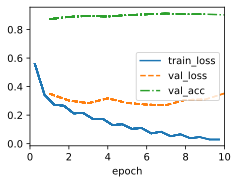

In [20]:
# Fashion-MNIST Training

trainer.fit(
    model,
    data,
)